# Emotion Detection Notebook
CNN-based model with Smart Greeting Feature

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plta
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [2]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'processed_data')

IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS = 10

print('Dataset folders:', os.listdir(DATA_DIR))

Dataset folders: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [3]:
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

class_names = train_ds.class_names
print('Classes:', class_names)

Found 49779 files belonging to 7 classes.
Using 39824 files for training.
Found 49779 files belonging to 7 classes.
Using 9955 files for validation.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [5]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 10, 10, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 4, 4, 128)         

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


1245/1245 [==============================] - 122s 97ms/step - loss: 1.6667 - accuracy: 0.3528 - val_loss: 1.3746 - val_accuracy: 0.5029
Epoch 2/10
1245/1245 [==============================] - 124s 100ms/step - loss: 1.3294 - accuracy: 0.5037 - val_loss: 1.2101 - val_accuracy: 0.5505
Epoch 3/10
1245/1245 [==============================] - 126s 101ms/step - loss: 1.2152 - accuracy: 0.5426 - val_loss: 1.1854 - val_accuracy: 0.5695
Epoch 4/10
1245/1245 [==============================] - 126s 101ms/step - loss: 1.1486 - accuracy: 0.5687 - val_loss: 1.1182 - val_accuracy: 0.5841
Epoch 5/10
1245/1245 [==============================] - 125s 101ms/step - loss: 1.0934 - accuracy: 0.5890 - val_loss: 1.0981 - val_accuracy: 0.5960
Epoch 6/10
1245/1245 [==============================] - 124s 100ms/step - loss: 1.0546 - accuracy: 0.6062 - val_loss: 1.0500 - val_accuracy: 0.6100
Epoch 7/10
1245/1245 [==============================] - 124s 99ms/step - loss: 1.0129 - accuracy: 0.6169 - val_

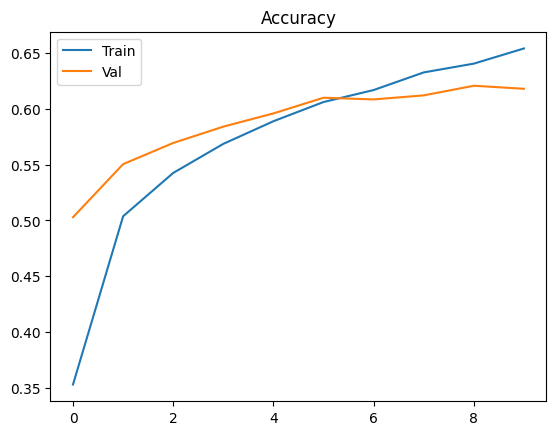

In [8]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title('Accuracy')
plt.show()

In [9]:
model.save('emotion_model.h5')
print('Model saved!')

Model saved!


c:\Users\CP\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
emotion_messages = {
    'happy': 'Great to see you happy!',
    'sad': 'Hope your day gets better.',
    'angry': 'Take a deep breath and stay calm.',
    'neutral': 'Have a productive day.',
    'surprise': 'Hope everything is going well.',
    'fear': 'Stay confident.',
    'disgust': 'Hope things improve soon.'
}

def smart_greeting(emotion):
    return emotion_messages.get(emotion, 'Welcome')

print(smart_greeting('happy'))

Great to see you happy!


In [11]:

# import tensorflow as tf
# print(tf.__version__)
